# Flexibilidad y Demand Side Management (DSM)

In [ ]:
from pathlib import Path
from datetime import timedelta
from dataclasses import dataclass, asdict
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import holidays

import scipy
from scipy.optimize import linprog

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)


Configuración y artefactos del modelo agregado:

In [ ]:
PROJECT_ROOT = Path()

PROCESSED_DIR = PROJECT_ROOT / 'processed'
FORECAST_ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts_aggregate_24h'
DSM_ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts_dsm'
DSM_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

AGGREGATE_FEATURES_PATH = PROCESSED_DIR / 'bilbao_ce_aggregate_features.parquet'
WEATHER_PATH = PROCESSED_DIR / 'bilbao_weather_hourly.parquet'
LOCAL_HOLIDAYS_CSV = PROCESSED_DIR / 'bilbao_local_holidays.csv'

FINAL_FEATURES_PATH = FORECAST_ARTIFACTS_DIR / 'final_features.pkl'
FINAL_CONFIG_PATH = FORECAST_ARTIFACTS_DIR / 'final_config.json'
MODEL_PATTERN = 'aggregate_h{h:02d}.pkl'

CONSUMPTION_TIMEZONE = 'UTC'
LOCAL_TIMEZONE = 'Europe/Madrid'
FORECAST_ORIGIN_LOCAL_HOUR = 23
FORECAST_HORIZON = 24

VAL_END = pd.Timestamp('2021-12-01 00:00:00')
TEST_END = pd.Timestamp('2022-06-01 00:00:00')
MAX_TARGET_IMPUTED_USER_FRAC = 0.05
RANDOM_SEED = 42

In [4]:
with open(FINAL_CONFIG_PATH, 'r', encoding='utf-8') as f:
    forecast_config = json.load(f)

FINAL_FEATURES = joblib.load(FINAL_FEATURES_PATH)
FORECAST_MODELS = {
    h: joblib.load(FORECAST_ARTIFACTS_DIR / MODEL_PATTERN.format(h=h))
    for h in range(1, 25)
}

print('Algoritmo:', forecast_config['algorithm'])
print('Miembros CE:', forecast_config['community_users'])
print('Features:', len(FINAL_FEATURES))
print('Modelos:', len(FORECAST_MODELS))

Algoritmo: XGBoost
Miembros CE: 923
Features: 104
Modelos: 24


Reconstruir las predicciones day-ahead del test:

In [5]:
features = pd.read_parquet(AGGREGATE_FEATURES_PATH)
features['Fecha'] = pd.to_datetime(features['Fecha'])

weather = pd.read_parquet(WEATHER_PATH)
weather['Fecha'] = pd.to_datetime(weather['Fecha'])
weather = weather.drop_duplicates('Fecha').sort_values('Fecha').set_index('Fecha')

print(features['Fecha'].min(), '→', features['Fecha'].max())

2019-05-31 01:00:00 → 2022-06-03 00:00:00


In [ ]:
years = range(features['Fecha'].min().year, features['Fecha'].max().year + 1)
pv_holidays = holidays.country_holidays('ES', subdiv='PV', years=years, language='es')
pv_holiday_dates = set(pv_holidays.keys())

bilbao_local_holiday_dates = set()
if LOCAL_HOLIDAYS_CSV.exists():
    local_holidays = pd.read_csv(LOCAL_HOLIDAYS_CSV)
    local_holidays['date'] = pd.to_datetime(local_holidays['date']).dt.date
    bilbao_local_holiday_dates = set(local_holidays['date'])

all_holiday_dates = pv_holiday_dates | bilbao_local_holiday_dates

In [ ]:
def local_datetime_index(values):
    return pd.DatetimeIndex(values).tz_localize(CONSUMPTION_TIMEZONE).tz_convert(LOCAL_TIMEZONE)

def add_holiday_columns(df):
    dates = df['target_date_local']
    df['is_public_holiday_pv'] = np.array([d in pv_holiday_dates for d in dates], dtype=np.uint8)
    df['is_bilbao_local_holiday'] = np.array([d in bilbao_local_holiday_dates for d in dates], dtype=np.uint8)
    df['is_holiday'] = np.maximum(df['is_public_holiday_pv'], df['is_bilbao_local_holiday']).astype('uint8')
    df['is_day_before_holiday'] = np.array([(d + timedelta(days=1)) in all_holiday_dates for d in dates], dtype=np.uint8)
    df['is_day_after_holiday'] = np.array([(d - timedelta(days=1)) in all_holiday_dates for d in dates], dtype=np.uint8)
    return df

In [ ]:
def make_horizon_dataset(feature_df, weather_df, horizon):
    df = feature_df.copy()
    target_time = df['Fecha'] + pd.to_timedelta(horizon, unit='h')
    df['target_time_utc'] = target_time
    df['target'] = df['consumo_ce'].shift(-horizon).astype('float32')
    df['target_imputed_user_frac'] = df['imputed_user_frac'].shift(-horizon).astype('float32')

    origin_local = local_datetime_index(df['Fecha'])
    target_local = local_datetime_index(target_time)
    df['origin_local_hour'] = np.asarray(origin_local.hour).astype('int8')
    df['target_date_local'] = np.asarray(target_local.date)

    hour = np.asarray(target_local.hour)
    dow = np.asarray(target_local.dayofweek)
    month = np.asarray(target_local.month)
    doy = np.asarray(target_local.dayofyear)

    df['target_hour'] = hour.astype('int8')
    df['target_dayofweek'] = dow.astype('int8')
    df['target_month'] = month.astype('int8')
    df['target_dayofyear'] = doy.astype('int16')
    df['target_is_weekend'] = (dow >= 5).astype('uint8')
    df['target_hour_sin'] = np.sin(2*np.pi*hour/24).astype('float32')
    df['target_hour_cos'] = np.cos(2*np.pi*hour/24).astype('float32')
    df['target_dow_sin'] = np.sin(2*np.pi*dow/7).astype('float32')
    df['target_dow_cos'] = np.cos(2*np.pi*dow/7).astype('float32')
    df['target_doy_sin'] = np.sin(2*np.pi*doy/365.25).astype('float32')
    df['target_doy_cos'] = np.cos(2*np.pi*doy/365.25).astype('float32')
    df = add_holiday_columns(df)

    wt = weather_df.reindex(pd.DatetimeIndex(target_time))
    mapping = {
        'temperature_2m':'target_temperature_2m',
        'apparent_temperature':'target_apparent_temperature',
        'relative_humidity_2m':'target_relative_humidity_2m',
        'precipitation':'target_precipitation',
        'cloud_cover':'target_cloud_cover',
        'wind_speed_10m':'target_wind_speed_10m',
    }
    for source, destination in mapping.items():
        df[destination] = wt[source].to_numpy(dtype='float32')

    df['target_heating_degree_15'] = np.maximum(15.0-df['target_temperature_2m'],0.0).astype('float32')
    df['target_cooling_degree_22'] = np.maximum(df['target_temperature_2m']-22.0,0.0).astype('float32')
    df['temperature_change_vs_origin'] = (df['target_temperature_2m']-df['origin_temperature_2m']).astype('float32')

    return df.dropna(subset=['target','load_lag_0h','same_hour_d28','load_mean_28d']).copy()

def get_test_rows(df):
    return df.loc[
        df['Fecha'].ge(VAL_END)
        & df['target_time_utc'].lt(TEST_END)
        & (df['origin_local_hour'] == FORECAST_ORIGIN_LOCAL_HOUR)
        & (df['target_imputed_user_frac'] <= MAX_TARGET_IMPUTED_USER_FRAC)
    ].copy()

In [9]:
prediction_parts=[]
for h in range(1,25):
    d = make_horizon_dataset(features, weather, h)
    test = get_test_rows(d)
    X = test[FINAL_FEATURES].replace([np.inf,-np.inf],np.nan).astype('float32')
    pred = np.maximum(FORECAST_MODELS[h].predict(X),0.0)
    prediction_parts.append(pd.DataFrame({
        'origin_time_utc':test['Fecha'].to_numpy(),
        'target_time_utc':test['target_time_utc'].to_numpy(),
        'horizon':h,
        'forecast':pred,
        'actual':test['target'].to_numpy(),
    }))

test_predictions = pd.concat(prediction_parts,ignore_index=True).sort_values(['origin_time_utc','horizon'])
complete_origins = test_predictions.groupby('origin_time_utc').size()
complete_origins = complete_origins.loc[complete_origins==24].index
test_predictions = test_predictions.loc[test_predictions['origin_time_utc'].isin(complete_origins)].copy()

print('Días completos:', test_predictions['origin_time_utc'].nunique())
display(test_predictions.head(30))

Días completos: 180


,origin_time_utc,target_time_utc,horizon,forecast,actual
0,2021-12-01 22:00:00,2021-12-01 23:00:00,1,338.040314,316.846008
182,2021-12-01 22:00:00,2021-12-02 00:00:00,2,256.900116,245.688995
364,2021-12-01 22:00:00,2021-12-02 01:00:00,3,183.676636,194.608002
545,2021-12-01 22:00:00,2021-12-02 02:00:00,4,141.240433,142.955002
725,2021-12-01 22:00:00,2021-12-02 03:00:00,5,123.646492,129.500000
906,2021-12-01 22:00:00,2021-12-02 04:00:00,6,123.562149,122.660004
1087,2021-12-01 22:00:00,2021-12-02 05:00:00,7,117.694443,120.918999
1268,2021-12-01 22:00:00,2021-12-02 06:00:00,8,123.030495,120.067001
1449,2021-12-01 22:00:00,2021-12-02 07:00:00,9,170.670624,163.005997
1630,2021-12-01 22:00:00,2021-12-02 08:00:00,10,260.621918,249.882996


Hipótesis de flexibilidad y dimensionamiento:

In [ ]:
historical_reference = features.loc[features['Fecha'] < VAL_END, 'consumo_ce'].dropna()
P95_HISTORICAL_LOAD = float(historical_reference.quantile(.95))
print('P95 histórico:', round(P95_HISTORICAL_LOAD,2), 'kWh/h')

P95 histórico: 331.17 kWh/h


In [ ]:
@dataclass
class DSMConfig:
    # Batería: por defecto ~2 h a la potencia P95
    battery_capacity_kwh: float = 2.0 * P95_HISTORICAL_LOAD
    battery_power_kw: float = 1.0 * P95_HISTORICAL_LOAD
    battery_eta_charge: float = 0.95
    battery_eta_discharge: float = 0.95
    battery_soc_min_frac: float = 0.10
    battery_soc_max_frac: float = 0.90
    battery_initial_soc_frac: float = 0.50

    # Shifting
    shiftable_power_fraction: float = 0.10
    max_shifted_energy_fraction: float = 0.05

    # Demand Response
    max_curtailment_fraction: float = 0.05
    max_daily_curtailment_fraction: float = 0.01
    dr_event_hours: int = 4

    # Penalizaciones de uso
    battery_throughput_penalty: float = 0.001
    shifting_penalty: float = 0.002
    curtailment_penalty: float = 0.05

DEFAULT_DSM_CONFIG = DSMConfig()
display(pd.DataFrame([asdict(DEFAULT_DSM_CONFIG)]).T.rename(columns={0:'valor'}))

,valor
battery_capacity_kwh,662.3334
battery_power_kw,331.1667
battery_eta_charge,0.9500
battery_eta_discharge,0.9500
battery_soc_min_frac,0.1000
battery_soc_max_frac,0.9000
battery_initial_soc_frac,0.5000
shiftable_power_fraction,0.1000
max_shifted_energy_fraction,0.0500
max_curtailment_fraction,0.0500


Optimizador DSM:

In [ ]:
def optimize_dsm_day(
    forecast,
    config=DEFAULT_DSM_CONFIG,
    use_battery=True,
    use_shifting=True,
    use_curtailment=True,
):
    """
    Optimización lineal DSM para un horizonte de 24 h.

    Variables:
        charge[t]       carga batería
        discharge[t]    descarga batería
        soc[t]          estado de carga
        shift_up[t]     carga flexible recibida
        shift_down[t]   carga flexible retirada
        curtail[t]      reducción DR
        peak            pico máximo gestionado

    Objetivo:
        minimizar peak + pequeñas penalizaciones de utilización.

    Se resuelve con scipy.optimize.linprog(method="highs").
    """

    forecast = np.asarray(forecast, dtype=float)
    n = len(forecast)

    if n != 24:
        raise ValueError("Se esperan exactamente 24 horas.")

    if np.any(~np.isfinite(forecast)):
        raise ValueError("El forecast contiene NaN o infinito.")

    if np.any(forecast < 0):
        raise ValueError("El forecast contiene demanda negativa.")

    # Índices de variables dentro del vector x
    i_charge = np.arange(0, n)
    i_discharge = np.arange(n, 2 * n)
    i_soc = np.arange(2 * n, 3 * n + 1)          # n + 1
    i_shift_up = np.arange(3 * n + 1, 4 * n + 1)
    i_shift_down = np.arange(4 * n + 1, 5 * n + 1)
    i_curtail = np.arange(5 * n + 1, 6 * n + 1)
    i_peak = 6 * n + 1

    n_vars = i_peak + 1

    # Función objetivo
    c = np.zeros(n_vars, dtype=float)

    c[i_peak] = 1.0

    c[i_charge] = config.battery_throughput_penalty
    c[i_discharge] = config.battery_throughput_penalty

    c[i_shift_up] = config.shifting_penalty
    c[i_shift_down] = config.shifting_penalty

    c[i_curtail] = config.curtailment_penalty

    # Bounds
    bounds = [(None, None)] * n_vars

    capacity = float(config.battery_capacity_kwh)
    initial_soc = (
        float(config.battery_initial_soc_frac)
        * capacity
    )

    # Batería
    if use_battery and capacity > 0:
        for idx in i_charge:
            bounds[idx] = (
                0.0,
                float(config.battery_power_kw),
            )

        for idx in i_discharge:
            bounds[idx] = (
                0.0,
                float(config.battery_power_kw),
            )

        soc_min = (
            float(config.battery_soc_min_frac)
            * capacity
        )

        soc_max = (
            float(config.battery_soc_max_frac)
            * capacity
        )

        for idx in i_soc:
            bounds[idx] = (
                soc_min,
                soc_max,
            )

    else:
        for idx in i_charge:
            bounds[idx] = (0.0, 0.0)

        for idx in i_discharge:
            bounds[idx] = (0.0, 0.0)

        for idx in i_soc:
            bounds[idx] = (
                initial_soc,
                initial_soc,
            )

    # Shifting
    if use_shifting:
        hourly_shift_cap = (
            float(config.shiftable_power_fraction)
            * forecast
        )

        for t in range(n):
            bounds[i_shift_up[t]] = (
                0.0,
                float(hourly_shift_cap[t]),
            )

            bounds[i_shift_down[t]] = (
                0.0,
                float(hourly_shift_cap[t]),
            )
    else:
        for idx in i_shift_up:
            bounds[idx] = (0.0, 0.0)

        for idx in i_shift_down:
            bounds[idx] = (0.0, 0.0)

    # Demand Response
    event_mask = np.zeros(n, dtype=float)

    if use_curtailment:
        n_event_hours = min(
            int(config.dr_event_hours),
            n,
        )

        event_idx = np.argsort(
            forecast
        )[-n_event_hours:]

        event_mask[event_idx] = 1.0

        curtail_cap = (
            float(config.max_curtailment_fraction)
            * forecast
            * event_mask
        )

        for t in range(n):
            bounds[i_curtail[t]] = (
                0.0,
                float(curtail_cap[t]),
            )
    else:
        for idx in i_curtail:
            bounds[idx] = (0.0, 0.0)

    bounds[i_peak] = (0.0, None)

    # Igualdades A_eq x = b_eq
    A_eq = []
    b_eq = []

    if use_battery and capacity > 0:
        # SOC inicial
        row = np.zeros(n_vars)
        row[i_soc[0]] = 1.0
        A_eq.append(row)
        b_eq.append(initial_soc)

        # soc[t+1] = soc[t] + eta_c*charge - discharge/eta_d
        eta_c = float(config.battery_eta_charge)
        eta_d = float(config.battery_eta_discharge)

        for t in range(n):
            row = np.zeros(n_vars)

            row[i_soc[t + 1]] = 1.0
            row[i_soc[t]] = -1.0
            row[i_charge[t]] = -eta_c
            row[i_discharge[t]] = 1.0 / eta_d

            A_eq.append(row)
            b_eq.append(0.0)

        # SOC final = SOC inicial
        row = np.zeros(n_vars)
        row[i_soc[n]] = 1.0
        A_eq.append(row)
        b_eq.append(initial_soc)

    # Conservación de energía desplazada: sum(shift_up) = sum(shift_down)
    if use_shifting:
        row = np.zeros(n_vars)
        row[i_shift_up] = 1.0
        row[i_shift_down] = -1.0

        A_eq.append(row)
        b_eq.append(0.0)

    A_eq = (
        np.vstack(A_eq)
        if A_eq
        else None
    )

    b_eq = (
        np.asarray(b_eq, dtype=float)
        if b_eq
        else None
    )

    # Desigualdades A_ub x <= b_ub
    A_ub = []
    b_ub = []

    for t in range(n):
        # managed_load >= 0
        #
        # forecast + charge - discharge + shift_up
        # - shift_down - curtail >= 0
        #
        # -charge + discharge - shift_up
        # + shift_down + curtail <= forecast
        row = np.zeros(n_vars)

        row[i_charge[t]] = -1.0
        row[i_discharge[t]] = 1.0
        row[i_shift_up[t]] = -1.0
        row[i_shift_down[t]] = 1.0
        row[i_curtail[t]] = 1.0

        A_ub.append(row)
        b_ub.append(float(forecast[t]))

        # managed_load <= peak
        #
        # forecast + charge - discharge + shift_up
        # - shift_down - curtail - peak <= 0
        #
        # charge - discharge + shift_up - shift_down
        # - curtail - peak <= -forecast
        row = np.zeros(n_vars)

        row[i_charge[t]] = 1.0
        row[i_discharge[t]] = -1.0
        row[i_shift_up[t]] = 1.0
        row[i_shift_down[t]] = -1.0
        row[i_curtail[t]] = -1.0
        row[i_peak] = -1.0

        A_ub.append(row)
        b_ub.append(-float(forecast[t]))

    # Límite de energía desplazada total
    if use_shifting:
        row = np.zeros(n_vars)
        row[i_shift_down] = 1.0

        A_ub.append(row)
        b_ub.append(
            float(
                config.max_shifted_energy_fraction
                * np.sum(forecast)
            )
        )

    # Límite diario de Demand Response
    if use_curtailment:
        row = np.zeros(n_vars)
        row[i_curtail] = 1.0

        A_ub.append(row)
        b_ub.append(
            float(
                config.max_daily_curtailment_fraction
                * np.sum(forecast)
            )
        )

    A_ub = np.vstack(A_ub)
    b_ub = np.asarray(
        b_ub,
        dtype=float,
    )

    # Resolver LP
    result = linprog(
        c=c,
        A_ub=A_ub,
        b_ub=b_ub,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method='highs',
    )

    if not result.success:
        raise RuntimeError(
            "La optimización DSM no ha convergido. "
            f"Estado: {result.status}. "
            f"Mensaje: {result.message}"
        )

    x = result.x

    charge = x[i_charge]
    discharge = x[i_discharge]
    soc = x[i_soc]
    shift_up = x[i_shift_up]
    shift_down = x[i_shift_down]
    curtail = x[i_curtail]
    peak = float(x[i_peak])

    managed = (
        forecast
        + charge
        - discharge
        + shift_up
        - shift_down
        - curtail
    )

    out = pd.DataFrame(
        {
            "hour": np.arange(1, n + 1),
            "forecast": forecast,
            "managed_forecast": managed,
            "charge": charge,
            "discharge": discharge,
            "shift_up": shift_up,
            "shift_down": shift_down,
            "curtailment": curtail,
            "dr_event": event_mask.astype(int),
            "soc_start": soc[:-1],
            "soc_end": soc[1:]
        }
    )

    out["net_dsm_adjustment"] = (
        out["managed_forecast"]
        - out["forecast"]
    )

    out.attrs["optimized_peak"] = peak
    out.attrs["solver_status"] = result.message
    out.attrs["objective_value"] = float(result.fun)

    return out

Día de mayor pico previsto:

In [14]:
forecast_days=[]
for origin,part in test_predictions.groupby('origin_time_utc'):
    forecast_days.append({
        'origin_time_utc':origin,
        'forecast_peak':part['forecast'].max(),
        'actual_peak':part['actual'].max(),
    })
forecast_days=pd.DataFrame(forecast_days).sort_values('forecast_peak',ascending=False)
EXAMPLE_ORIGIN=forecast_days.iloc[0]['origin_time_utc']
example=test_predictions.loc[test_predictions['origin_time_utc']==EXAMPLE_ORIGIN].sort_values('horizon').copy()
print('Origen:',EXAMPLE_ORIGIN)

Origen: 2022-01-16 22:00:00


In [ ]:
example_dsm=optimize_dsm_day(example['forecast'],DEFAULT_DSM_CONFIG,True,True,True)
example_dsm['actual']=example['actual'].to_numpy()
example_dsm['managed_actual']=example_dsm['actual']+example_dsm['net_dsm_adjustment']
display(example_dsm)

,hour,forecast,managed_forecast,charge,discharge,shift_up,shift_down,curtailment,dr_event,soc_start,soc_end,net_dsm_adjustment,actual,managed_actual
0,1,333.930359,261.487221,0.000000,72.443138,0.000000,0.000000,0.000000,1,331.166700,254.910765,-72.443138,335.105988,262.662849
1,2,267.934479,261.487221,0.000000,6.447258,0.000000,0.000000,0.000000,0,254.910765,248.124177,-6.447258,248.792999,242.345741
2,3,188.915070,207.806577,0.000000,0.000000,18.891507,0.000000,0.000000,0,248.124177,248.124177,18.891507,180.738007,199.629514
3,4,146.438843,161.082727,0.000000,0.000000,14.643884,0.000000,0.000000,0,248.124177,248.124177,14.643884,136.798996,151.442880
4,5,126.380363,139.018400,0.000000,0.000000,12.638036,0.000000,0.000000,0,248.124177,248.124177,12.638036,130.175003,142.813039
5,6,130.655655,190.191937,46.470717,0.000000,13.065565,0.000000,0.000000,0,248.124177,292.271359,59.536282,128.022003,187.558286
6,7,132.313461,261.487221,115.942413,0.000000,13.231346,0.000000,0.000000,0,292.271359,402.416651,129.173759,124.575500,253.749260
7,8,129.373810,261.487221,119.176030,0.000000,12.937381,0.000000,0.000000,0,402.416651,515.633879,132.113411,130.108994,262.222404
8,9,166.319855,261.487221,78.535380,0.000000,16.631985,0.000000,0.000000,0,515.633879,590.242491,95.167366,178.163498,273.330864
9,10,242.661011,261.487221,0.000000,0.000000,18.826210,0.000000,0.000000,0,590.242491,590.242491,18.826210,262.729492,281.555702


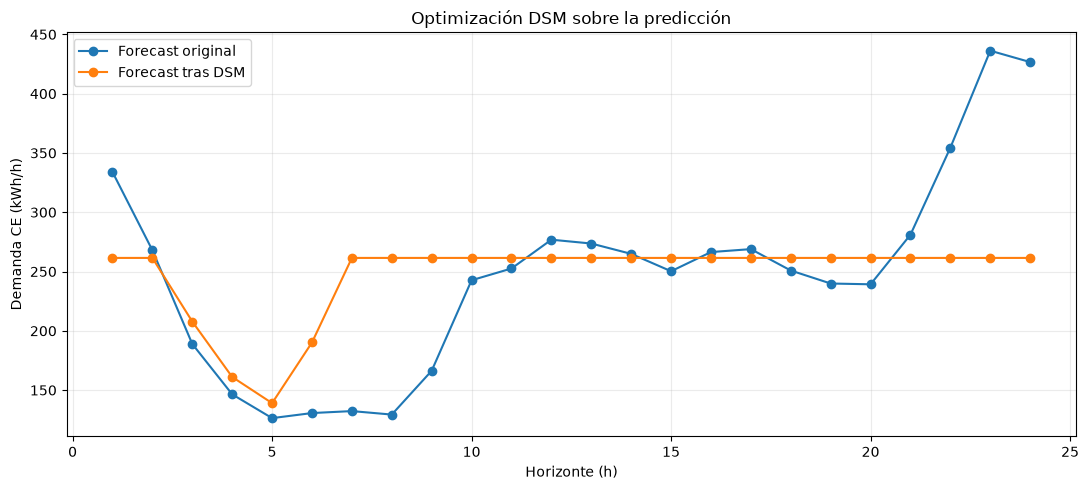

In [16]:
plt.figure(figsize=(11,5))
plt.plot(example_dsm['hour'],example_dsm['forecast'],marker='o',label='Forecast original')
plt.plot(example_dsm['hour'],example_dsm['managed_forecast'],marker='o',label='Forecast tras DSM')
plt.xlabel('Horizonte (h)'); plt.ylabel('Demanda CE (kWh/h)')
plt.title('Optimización DSM sobre la predicción'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

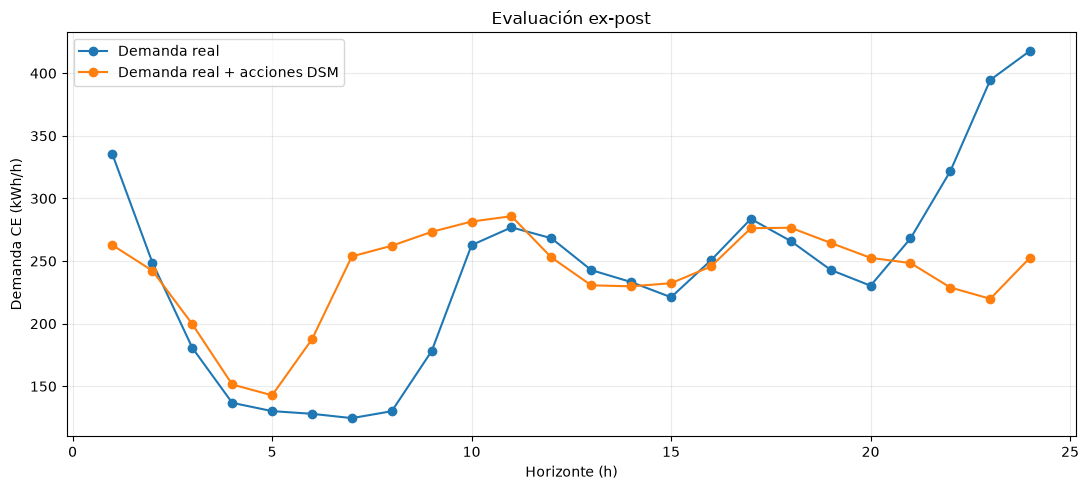

In [17]:
plt.figure(figsize=(11,5))
plt.plot(example_dsm['hour'],example_dsm['actual'],marker='o',label='Demanda real')
plt.plot(example_dsm['hour'],example_dsm['managed_actual'],marker='o',label='Demanda real + acciones DSM')
plt.xlabel('Horizonte (h)'); plt.ylabel('Demanda CE (kWh/h)')
plt.title('Evaluación ex-post'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

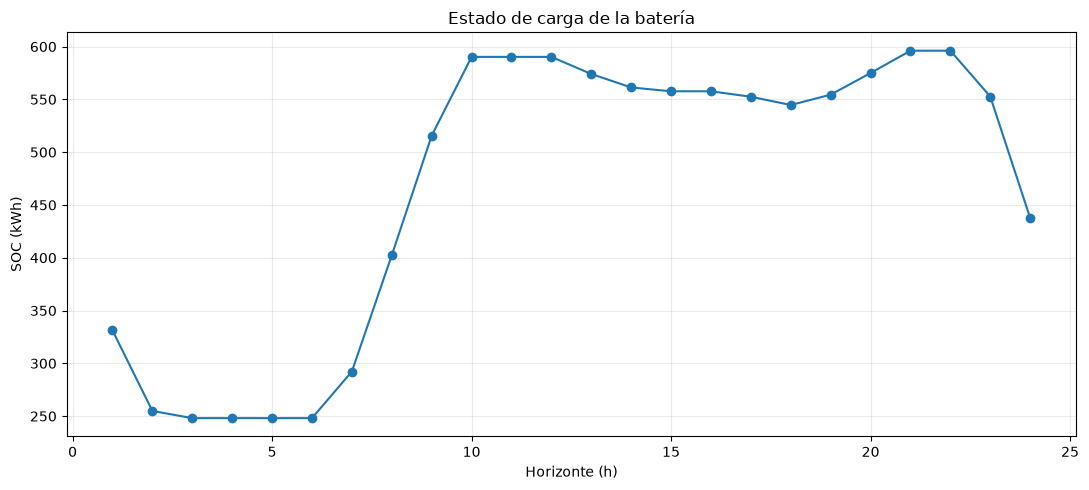

In [18]:
plt.figure(figsize=(11,5))
plt.plot(example_dsm['hour'],example_dsm['soc_start'],marker='o')
plt.xlabel('Horizonte (h)'); plt.ylabel('SOC (kWh)')
plt.title('Estado de carga de la batería'); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

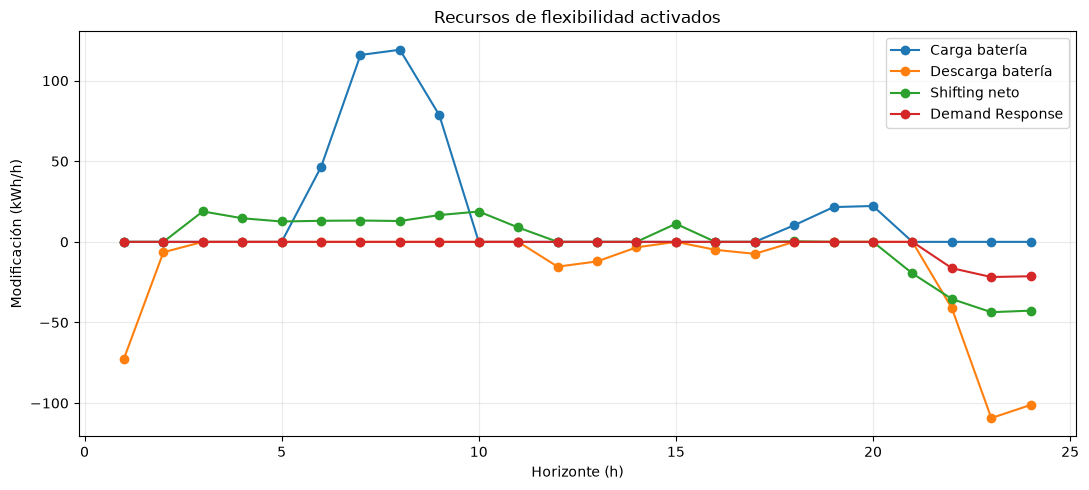

In [19]:
plt.figure(figsize=(11,5))
plt.plot(example_dsm['hour'],example_dsm['charge'],marker='o',label='Carga batería')
plt.plot(example_dsm['hour'],-example_dsm['discharge'],marker='o',label='Descarga batería')
plt.plot(example_dsm['hour'],example_dsm['shift_up']-example_dsm['shift_down'],marker='o',label='Shifting neto')
plt.plot(example_dsm['hour'],-example_dsm['curtailment'],marker='o',label='Demand Response')
plt.xlabel('Horizonte (h)'); plt.ylabel('Modificación (kWh/h)')
plt.title('Recursos de flexibilidad activados'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

Métricas DSM:

In [ ]:
def dsm_metrics(dsm_result):
    f=dsm_result['forecast'].to_numpy()
    mf=dsm_result['managed_forecast'].to_numpy()
    a=dsm_result['actual'].to_numpy()
    ma=dsm_result['managed_actual'].to_numpy()

    def reduction(before,after):
        return 100*(np.max(before)-np.max(after))/max(np.max(before),1e-8)

    return {
        'forecast_peak_before':np.max(f),
        'forecast_peak_after':np.max(mf),
        'forecast_peak_reduction_pct':reduction(f,mf),
        'actual_peak_before':np.max(a),
        'actual_peak_after':np.max(ma),
        'actual_peak_reduction_pct':reduction(a,ma),
        'forecast_load_factor_before':np.mean(f)/np.max(f),
        'forecast_load_factor_after':np.mean(mf)/np.max(mf),
        'actual_load_factor_before':np.mean(a)/np.max(a),
        'actual_load_factor_after':np.mean(ma)/np.max(ma),
        'shifted_energy_kwh':dsm_result['shift_down'].sum(),
        'battery_charge_kwh':dsm_result['charge'].sum(),
        'battery_discharge_kwh':dsm_result['discharge'].sum(),
        'battery_throughput_kwh':dsm_result['charge'].sum()+dsm_result['discharge'].sum(),
        'curtailed_energy_kwh':dsm_result['curtailment'].sum(),
        'actual_energy_before_kwh':np.sum(a),
        'actual_energy_after_kwh':np.sum(ma),
        'negative_realized_hours':int((ma < -1e-6).sum())
    }

display(pd.DataFrame([dsm_metrics(example_dsm)]).T)

,0
forecast_peak_before,436.237885
forecast_peak_after,261.487221
forecast_peak_reduction_pct,40.058571
actual_peak_before,417.996002
actual_peak_after,285.835945
actual_peak_reduction_pct,31.617541
forecast_load_factor_before,0.568012
forecast_load_factor_after,0.944572
actual_load_factor_before,0.575525
actual_load_factor_after,0.838846


Comparación Shifting, Battery, Demand Response y caso combinado:

In [21]:
DSM_SCENARIOS={
    'Shifting':dict(use_battery=False,use_shifting=True,use_curtailment=False),
    'Battery':dict(use_battery=True,use_shifting=False,use_curtailment=False),
    'Demand_Response':dict(use_battery=False,use_shifting=False,use_curtailment=True),
    'Combined':dict(use_battery=True,use_shifting=True,use_curtailment=True),
}

In [22]:
def evaluate_dsm_scenario(prediction_df, scenario_name, scenario_kwargs, config=DEFAULT_DSM_CONFIG):
    rows=[]
    origins=prediction_df['origin_time_utc'].drop_duplicates().sort_values()
    for origin in origins:
        day=prediction_df.loc[prediction_df['origin_time_utc']==origin].sort_values('horizon')
        if len(day)!=24:
            continue
        opt=optimize_dsm_day(day['forecast'],config=config,**scenario_kwargs)
        opt['actual']=day['actual'].to_numpy()
        opt['managed_actual']=opt['actual']+opt['net_dsm_adjustment']
        row={'origin_time_utc':origin,'scenario':scenario_name}
        row.update(dsm_metrics(opt))
        rows.append(row)
    return pd.DataFrame(rows)

In [23]:
scenario_results=[]
for name,kwargs in DSM_SCENARIOS.items():
    print('Evaluando:',name)
    scenario_results.append(evaluate_dsm_scenario(test_predictions,name,kwargs))

scenario_results=pd.concat(scenario_results,ignore_index=True)
scenario_results.to_csv(DSM_ARTIFACTS_DIR/'dsm_scenario_results.csv',index=False)
print('Filas:',len(scenario_results))

Evaluando: Shifting
Evaluando: Battery
Evaluando: Demand_Response
Evaluando: Combined
Filas: 720


In [24]:
scenario_summary=(
    scenario_results.groupby('scenario').agg(
        days=('origin_time_utc','nunique'),
        forecast_peak_reduction_mean_pct=('forecast_peak_reduction_pct','mean'),
        actual_peak_reduction_mean_pct=('actual_peak_reduction_pct','mean'),
        actual_peak_reduction_median_pct=('actual_peak_reduction_pct','median'),
        actual_load_factor_before=('actual_load_factor_before','mean'),
        actual_load_factor_after=('actual_load_factor_after','mean'),
        shifted_energy_mean_kwh=('shifted_energy_kwh','mean'),
        battery_throughput_mean_kwh=('battery_throughput_kwh','mean'),
        curtailed_energy_mean_kwh=('curtailed_energy_kwh','mean'),
        negative_realized_hours=('negative_realized_hours','sum'),
    ).sort_values('actual_peak_reduction_mean_pct',ascending=False)
)
display(scenario_summary)
scenario_summary.to_csv(DSM_ARTIFACTS_DIR/'dsm_scenario_summary.csv')

,days,forecast_peak_reduction_mean_pct,actual_peak_reduction_mean_pct,actual_peak_reduction_median_pct,actual_load_factor_before,actual_load_factor_after,shifted_energy_mean_kwh,battery_throughput_mean_kwh,curtailed_energy_mean_kwh,negative_realized_hours
scenario,,,,,,,,,,
Combined,180,34.449353,26.829795,28.312455,0.629563,0.866121,153.278659,780.798839,29.694042,0
Battery,180,30.178319,22.702491,23.232957,0.629563,0.825715,0.000000,777.605674,0.000000,0
Shifting,180,10.000000,5.887718,6.700876,0.629563,0.668991,51.680410,0.000000,0.000000,0
Demand_Response,180,4.996809,3.062946,3.970807,0.629563,0.646629,0.000000,0.000000,19.943194,0


Forecast vs beneficio DSM realmente obtenido:

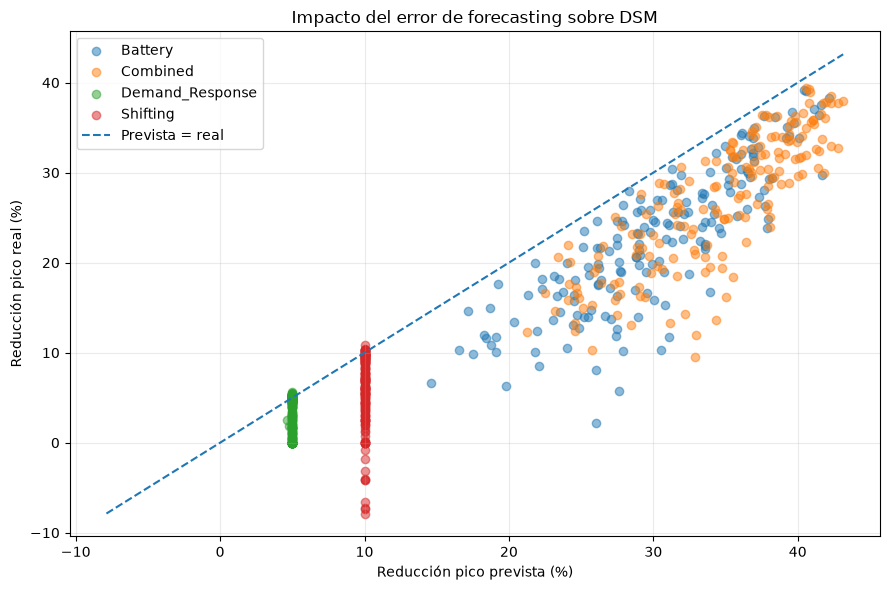

In [25]:
plt.figure(figsize=(9,6))
for scenario,part in scenario_results.groupby('scenario'):
    plt.scatter(part['forecast_peak_reduction_pct'],part['actual_peak_reduction_pct'],alpha=.5,label=scenario)

lo=min(scenario_results['forecast_peak_reduction_pct'].min(),scenario_results['actual_peak_reduction_pct'].min())
hi=max(scenario_results['forecast_peak_reduction_pct'].max(),scenario_results['actual_peak_reduction_pct'].max())
plt.plot([lo,hi],[lo,hi],linestyle='--',label='Prevista = real')
plt.xlabel('Reducción pico prevista (%)'); plt.ylabel('Reducción pico real (%)')
plt.title('Impacto del error de forecasting sobre DSM'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

Distribución de beneficios DSM:

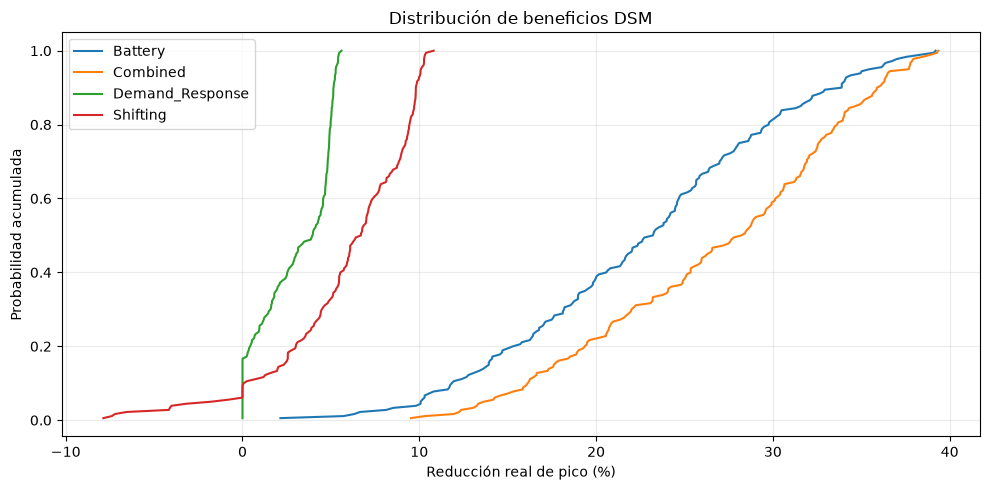

In [26]:
plt.figure(figsize=(10,5))
for scenario,part in scenario_results.groupby('scenario'):
    values=np.sort(part['actual_peak_reduction_pct'].to_numpy())
    cdf=np.arange(1,len(values)+1)/len(values)
    plt.plot(values,cdf,label=scenario)
plt.xlabel('Reducción real de pico (%)'); plt.ylabel('Probabilidad acumulada')
plt.title('Distribución de beneficios DSM'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

Análisis de sensibilidad:

In [27]:
SENSITIVITY_BATTERY_HOURS=[0.0,1.0,2.0,3.0]
SENSITIVITY_SHIFTABLE_FRACTIONS=[0.00,0.05,0.10,0.15]
N_SENSITIVITY_DAYS=20
sensitivity_origins=forecast_days.head(N_SENSITIVITY_DAYS)['origin_time_utc'].tolist()

In [28]:
sensitivity_rows=[]
for battery_hours in SENSITIVITY_BATTERY_HOURS:
    for shift_fraction in SENSITIVITY_SHIFTABLE_FRACTIONS:
        cfg=DSMConfig(
            battery_capacity_kwh=battery_hours*P95_HISTORICAL_LOAD,
            battery_power_kw=P95_HISTORICAL_LOAD if battery_hours>0 else 0.0,
            shiftable_power_fraction=shift_fraction,
            max_shifted_energy_fraction=min(0.50*shift_fraction,0.075),
            max_curtailment_fraction=0.0,
            max_daily_curtailment_fraction=0.0,
        )
        reductions=[]
        for origin in sensitivity_origins:
            day=test_predictions.loc[test_predictions['origin_time_utc']==origin].sort_values('horizon')
            opt=optimize_dsm_day(
                day['forecast'],cfg,
                use_battery=battery_hours>0,
                use_shifting=shift_fraction>0,
                use_curtailment=False,
            )
            opt['actual']=day['actual'].to_numpy()
            opt['managed_actual']=opt['actual']+opt['net_dsm_adjustment']
            reductions.append(dsm_metrics(opt)['actual_peak_reduction_pct'])
        sensitivity_rows.append({
            'battery_hours':battery_hours,
            'shiftable_fraction':shift_fraction,
            'mean_actual_peak_reduction_pct':np.mean(reductions),
            'median_actual_peak_reduction_pct':np.median(reductions),
        })

sensitivity=pd.DataFrame(sensitivity_rows)
display(sensitivity)
sensitivity.to_csv(DSM_ARTIFACTS_DIR/'dsm_sensitivity.csv',index=False)

,battery_hours,shiftable_fraction,mean_actual_peak_reduction_pct,median_actual_peak_reduction_pct
0,0.0,0.00,0.000000,0.000000
1,0.0,0.05,2.295913,2.933946
2,0.0,0.10,6.925054,7.776721
3,0.0,0.15,11.587345,12.532709
4,1.0,0.00,13.652718,14.137305
5,1.0,0.05,17.999583,17.543259
6,1.0,0.10,21.805630,21.587307
7,1.0,0.15,25.585458,25.450143
8,2.0,0.00,23.144926,23.232957
9,2.0,0.05,27.171669,27.568472


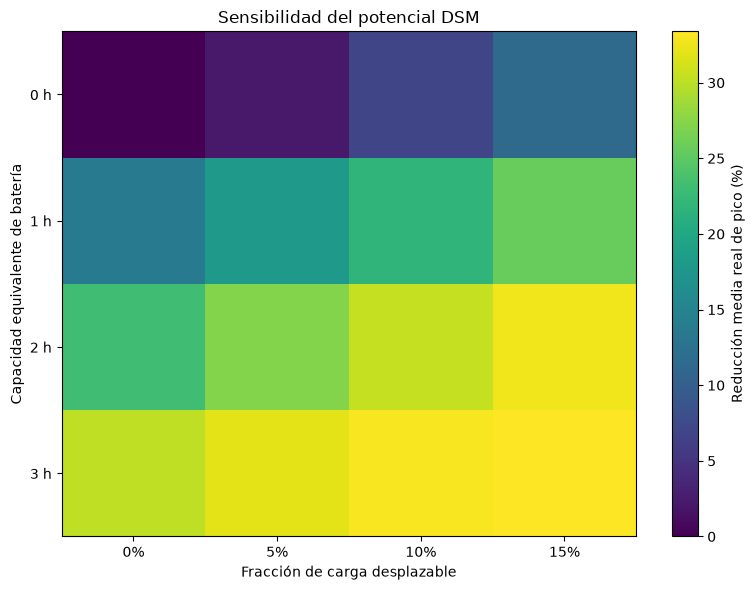

In [29]:
heatmap=sensitivity.pivot(index='battery_hours',columns='shiftable_fraction',values='mean_actual_peak_reduction_pct')
plt.figure(figsize=(8,6))
image=plt.imshow(heatmap.to_numpy(),aspect='auto')
plt.colorbar(image,label='Reducción media real de pico (%)')
plt.xticks(np.arange(len(heatmap.columns)),[f'{100*x:.0f}%' for x in heatmap.columns])
plt.yticks(np.arange(len(heatmap.index)),[f'{x:.0f} h' for x in heatmap.index])
plt.xlabel('Fracción de carga desplazable'); plt.ylabel('Capacidad equivalente de batería')
plt.title('Sensibilidad del potencial DSM'); plt.tight_layout(); plt.show()

Simulación explícita de un evento de Demand Response:

In [30]:
dr_example=optimize_dsm_day(example['forecast'],DEFAULT_DSM_CONFIG,False,False,True)
dr_example['actual']=example['actual'].to_numpy()
dr_example['managed_actual']=dr_example['actual']+dr_example['net_dsm_adjustment']
display(dr_example.loc[dr_example['dr_event']==1,['hour','forecast','actual','curtailment','managed_actual']])

,hour,forecast,actual,curtailment,managed_actual
0,1,333.930359,335.105988,0.000000,335.105988
21,22,354.470093,321.872986,0.000000,321.872986
22,23,436.237885,394.634003,21.811894,372.822108
23,24,426.644897,417.996002,12.218907,405.777095


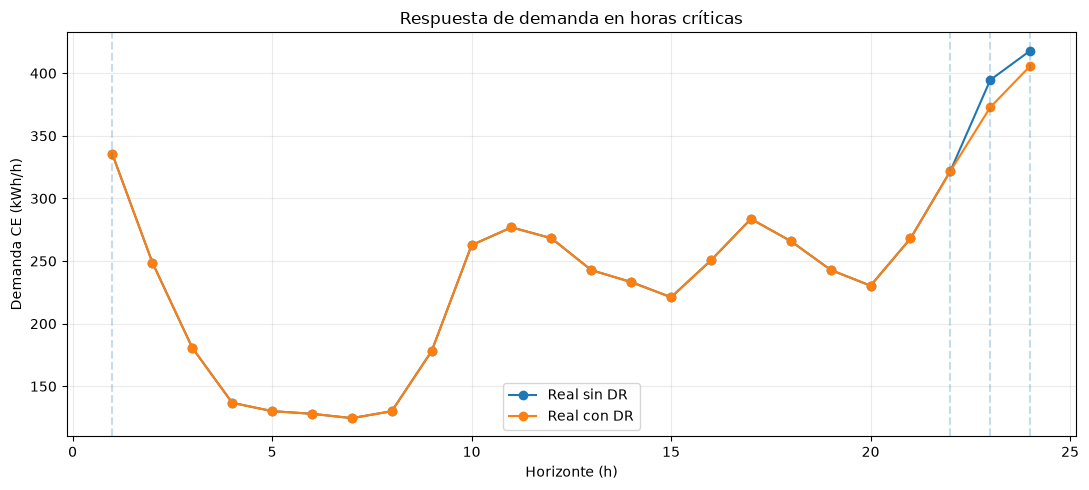

In [31]:
plt.figure(figsize=(11,5))
plt.plot(dr_example['hour'],dr_example['actual'],marker='o',label='Real sin DR')
plt.plot(dr_example['hour'],dr_example['managed_actual'],marker='o',label='Real con DR')
for h in dr_example.loc[dr_example['dr_event']==1,'hour']:
    plt.axvline(h,linestyle='--',alpha=.25)
plt.xlabel('Horizonte (h)'); plt.ylabel('Demanda CE (kWh/h)')
plt.title('Respuesta de demanda en horas críticas'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

Peak-to-Average Ratio (PAR):

In [32]:
par_rows=[]
for scenario,part in scenario_results.groupby('scenario'):
    before=1.0/part['actual_load_factor_before']
    after=1.0/part['actual_load_factor_after']
    par_rows.append({
        'scenario':scenario,
        'PAR_before_mean':before.mean(),
        'PAR_after_mean':after.mean(),
        'PAR_reduction_pct':100*(before.mean()-after.mean())/before.mean(),
    })
par_summary=pd.DataFrame(par_rows)
display(par_summary)

,scenario,PAR_before_mean,PAR_after_mean,PAR_reduction_pct
0,Battery,1.598544,1.218321,23.785574
1,Combined,1.598544,1.159279,27.479087
2,Demand_Response,1.598544,1.555369,2.700907
3,Shifting,1.598544,1.502053,6.036204


Perfect Foresight:

In [ ]:
perfect_rows=[]
for origin in complete_origins:
    day=test_predictions.loc[test_predictions['origin_time_utc']==origin].sort_values('horizon')
    oracle=optimize_dsm_day(day['actual'],DEFAULT_DSM_CONFIG,True,True,True)
    before=day['actual'].to_numpy()
    after=oracle['managed_forecast'].to_numpy()
    perfect_rows.append({
        'origin_time_utc':origin,
        'perfect_foresight_peak_reduction_pct':100*(before.max()-after.max())/before.max(),
    })
perfect_foresight=pd.DataFrame(perfect_rows)
combined_real=(
    scenario_results.loc[scenario_results['scenario']=='Combined',['origin_time_utc','actual_peak_reduction_pct']]
    .merge(perfect_foresight,on='origin_time_utc',how='inner')
)
combined_real['forecasting_cost_pct_points']=(
    combined_real['perfect_foresight_peak_reduction_pct']-combined_real['actual_peak_reduction_pct']
)
display(combined_real[['actual_peak_reduction_pct','perfect_foresight_peak_reduction_pct','forecasting_cost_pct_points']].describe())

,actual_peak_reduction_pct,perfect_foresight_peak_reduction_pct,forecasting_cost_pct_points
count,180.000000,180.000000,180.000000
mean,26.829795,35.207381,8.377586
std,7.386668,5.469607,3.774128
min,9.531388,21.958671,2.737020
25%,20.775854,30.647440,5.523059
50%,28.312455,35.846036,7.321199
75%,32.607572,39.418119,10.455901
max,39.354004,46.195977,23.179998
